In [13]:
from collections import defaultdict
import random

import numpy as np
import pandas as pd
import networkx as nx
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import seaborn as sns

# Загрузка данных

In [3]:
df = pd.read_csv(r'C:\Users\Anast.Andreeva1\.cache\kagglehub\datasets\vikalpdongre\us-flights-data-2008\versions\1\2008.csv')

In [4]:
df = df[df['Cancelled'] == 0] # Только выполненные рейсы
print(f"Всего рейсов: {len(df)}")

Всего рейсов: 6872294


In [5]:
print("Доступные колонки:", df.columns.tolist())
print("\nПервые строки:")
print(df[['Origin', 'Dest']].head())

Доступные колонки: ['Year', 'Month', 'DayofMonth', 'DayOfWeek', 'DepTime', 'CRSDepTime', 'ArrTime', 'CRSArrTime', 'UniqueCarrier', 'FlightNum', 'TailNum', 'ActualElapsedTime', 'CRSElapsedTime', 'AirTime', 'ArrDelay', 'DepDelay', 'Origin', 'Dest', 'Distance', 'TaxiIn', 'TaxiOut', 'Cancelled', 'CancellationCode', 'Diverted', 'CarrierDelay', 'WeatherDelay', 'NASDelay', 'SecurityDelay', 'LateAircraftDelay']

Первые строки:
  Origin Dest
0    IAD  TPA
1    IAD  TPA
2    IND  BWI
3    IND  BWI
4    IND  BWI


In [6]:
## Создаю направленный взвешенный граф

G = nx.from_pandas_edgelist(
    df, 
    source='Origin', 
    target='Dest', 
    create_using=nx.MultiDiGraph()
)

print(f"\n Граф")
print(f"Узлов (аэропортов): {G.number_of_nodes()}")
print(f"Рёбер (рейсов): {G.number_of_edges()}")


 Граф
Узлов (аэропортов): 305
Рёбер (рейсов): 6872294


# Визуализация графа

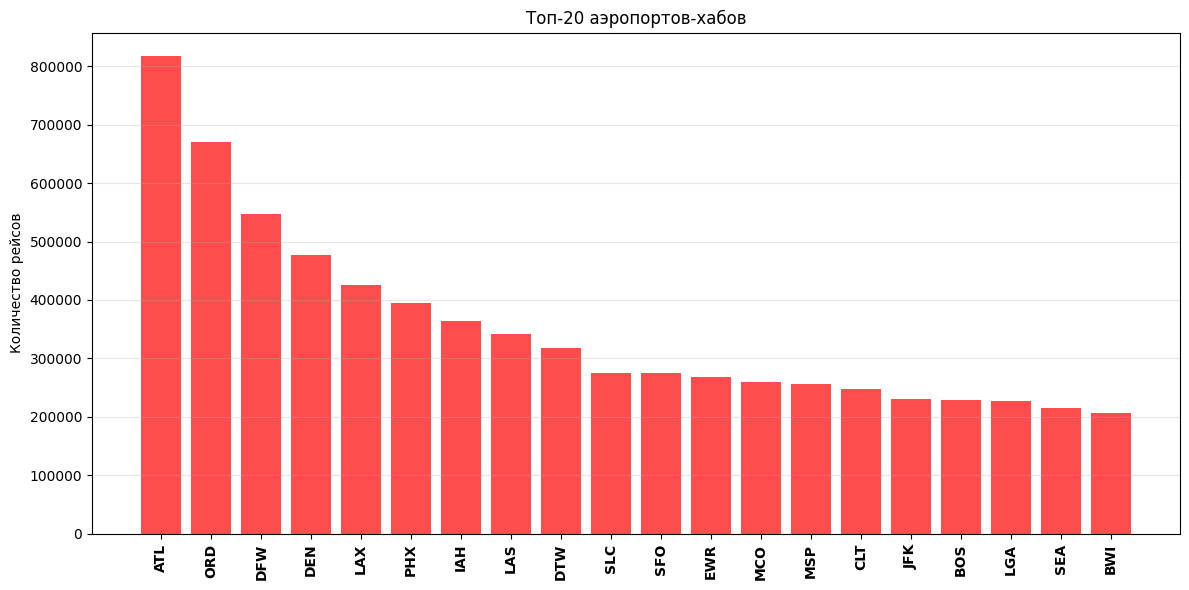

   Аэропорт  Рейсов
0       ATL  816499
1       ORD  669688
2       DFW  547694
3       DEN  477204
4       LAX  425378
5       PHX  394395
6       IAH  363705
7       LAS  341885
8       DTW  318411
9       SLC  275740
10      SFO  275392
11      EWR  267878
12      MCO  259628
13      MSP  256892
14      CLT  247862
15      JFK  231210
16      BOS  228603
17      LGA  226778
18      SEA  215839
19      BWI  206176


In [7]:
# Топ-20 сортируется по степени узла (degree), это количество исходящих + входящих рейсов из каждого аэропорта.

hubs = sorted(G.degree(), key=lambda x: x [1], reverse=True)[:20]
hubs_df = pd.DataFrame(hubs, columns=['Аэропорт', 'Рейсов'])

plt.figure(figsize=(12, 6))
plt.bar(range(20), hubs_df['Рейсов'], color='red', alpha=0.7)
plt.xticks(range(20), hubs_df['Аэропорт'], rotation=90, fontweight='bold')
plt.ylabel('Количество рейсов')
plt.title('Топ-20 аэропортов-хабов')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(hubs_df)


# Моделирование распространения инфекции в сети авиаперелётов

In [8]:
def simulate_si(graph, start_node, p=0.1, max_steps=1000):
    states = {node: 'S' for node in graph.nodes()}
    states[start_node] = 'I'
    infected_history =  [1]
    
    # каждый маршрут = 1 рейс
    all_flights = list(graph.edges())  # Все рёбра
    random.shuffle(all_flights)
    
    for step, (origin, dest) in enumerate(all_flights[:max_steps]):
        if states[origin] == 'I' and states[dest] == 'S':
            if random.random() < p:
                states[dest] = 'I'
        
        infected_count = sum(1 for v in states.values() if v == 'I')
        infected_history.append(infected_count)
        
        if infected_count == len(graph.nodes()):
            break
    
    return states, infected_history


# Быстрая проверка SI на сети аэропортов

In [9]:
def quick_sim_test(graph, start_nodes, p=0.05, n_runs=2, max_steps=200):
    results = {}
    total_nodes = len(graph.nodes())
    
    for start in start_nodes[:3]:  # Только 3 стартовых!
        infected = 0
        for _ in range(n_runs):
            states, _ = simulate_si(graph, start, p, max_steps)
            infected += sum(1 for v in states.values() if v == 'I')
        results[start] = round(infected / (n_runs * total_nodes) * 100, 1)
    
    return results

top_hubs = [node for node, _ in sorted(G.degree(), key=lambda x: x [1], reverse=True)[:3]]
random_airports = random.sample(list(G.nodes()), 3)

all_starts = top_hubs + random_airports
print("Запуск теста:", all_starts)

results = quick_sim_test(G, all_starts, p=0.05)
print("\nРЕЗУЛЬТАТ:")
for airport, pct in results.items():
    print(f"{airport}: {pct}% заражённых")



Запуск теста: ['ATL', 'ORD', 'DFW', 'MCI', 'CLE', 'GGG']

РЕЗУЛЬТАТ:
ATL: 0.8% заражённых
ORD: 0.8% заражённых
DFW: 0.3% заражённых


# Функция симуляции

In [10]:
def simulate_infection_single_pass(df, start_airport, p):
    infected = set([start_airport])
    infection_time = {start_airport: 0}
    flight_idx = 0
    
    for row in df.itertuples():
        origin, dest = row.Origin, row.Dest
        flight_idx += 1
        
        if origin in infected and dest not in infected:
            if np.random.random() < p:
                infected.add(dest)
                infection_time[dest] = flight_idx
    
    return infection_time

# Тест
start = 'ABE' 
times = simulate_infection_single_pass(df, start, p=0.1)
print(f"Заражено за {max(times.values())} рейсов: {len(times)} аэропортов")


Заражено за 5412700 рейсов: 301 аэропортов


# Влияние инфекционности p на скорость распространения

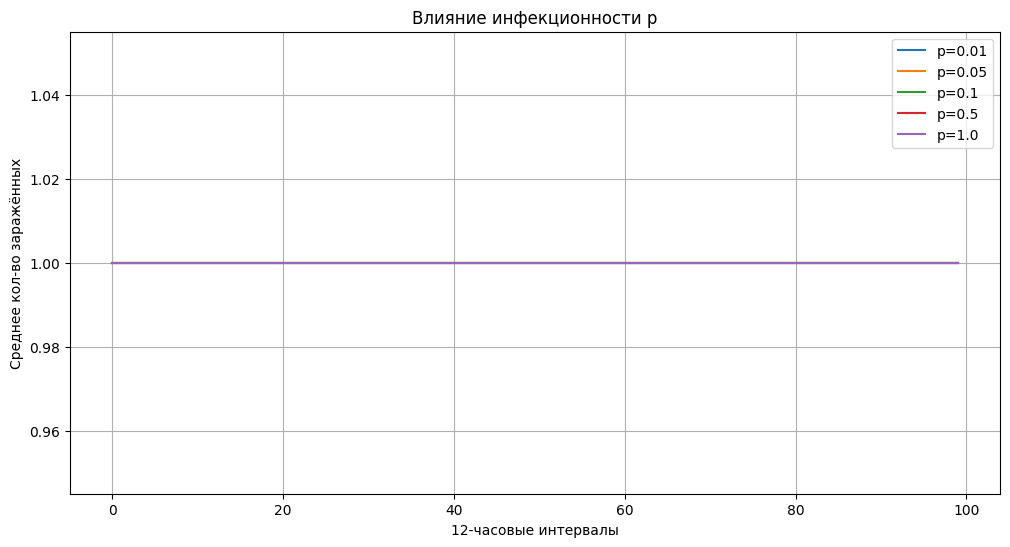

In [11]:
def analyze_p(df, start_airport, p_values, n_sims=5, interval=12):
    results = {}
    for p in p_values:
        infected_over_time = []
        for _ in range(n_sims):
            times = simulate_infection_single_pass(df, start_airport, p)
            # Каждые 12 часов
            hourly = [sum(1 for t in times.values() if t <= i*interval) 
                     for i in range(100)]
            infected_over_time.append(hourly)
        results[p] = np.mean(infected_over_time, axis=0)
    return results

p_vals = [0.01, 0.05, 0.1, 0.5, 1.0]
p_results = analyze_p(df, 'ABE', p_vals, n_sims=3)

plt.figure(figsize=(12, 6))
for p, data in p_results.items():
    plt.plot(data, label=f'p={p}')
plt.xlabel('12-часовые интервалы')
plt.ylabel('Среднее кол-во заражённых')
plt.title('Влияние инфекционности p')
plt.legend()
plt.grid(True)
plt.show()


# NetworkX метрики + корреляции

c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\_core\fromnumeric.py:3596: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\Anast.Andreeva1\AppData\Local\Programs\Python\Python39\lib\site-packages\numpy\_core\_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


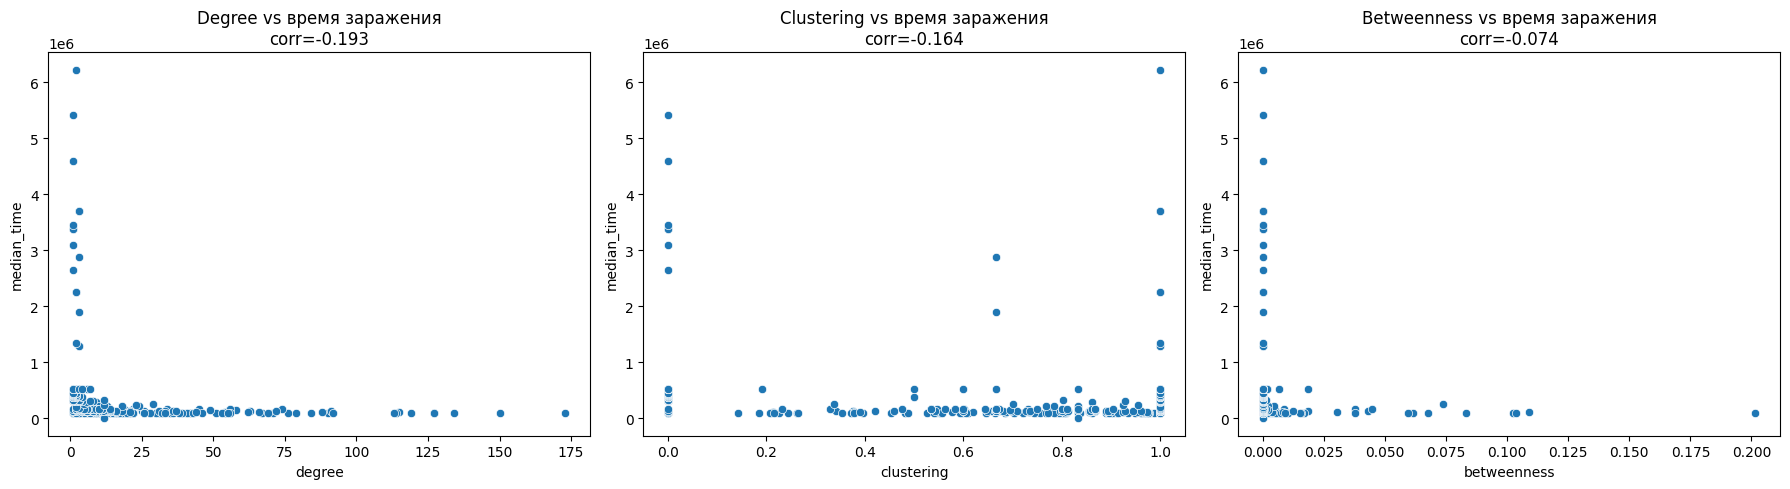

КОРРЕЛЯЦИИ:
               degree  clustering  betweenness  median_time
degree       1.000000   -0.197322     0.758378    -0.192901
clustering  -0.197322    1.000000    -0.248220    -0.164403
betweenness  0.758378   -0.248220     1.000000    -0.073758
median_time -0.192901   -0.164403    -0.073758     1.000000


In [14]:
# Граф с весами
flight_counts = defaultdict(int)
for _, row in df.iterrows():
    u, v = min(row.Origin, row.Dest), max(row.Origin, row.Dest)
    flight_counts[(u, v)] += 1

total_flights = sum(flight_counts.values())
G_undir = nx.Graph()
for (u, v), count in flight_counts.items():
    G_undir.add_edge(u, v, weight=count/total_flights)

# 20 симуляций (не 50 — быстро!)
def run_sims(df, start, p=0.5, n_sims=20):
    all_times = []
    for _ in range(n_sims):
        times = simulate_infection_single_pass(df, start, p)
        all_times.append(times)
    return all_times

all_times = run_sims(df, 'ABE', p=0.5, n_sims=20)

# Медианное время заражения
median_times = {}
for airport in G_undir.nodes():
    times_list = [sim.get(airport, float('inf')) for sim in all_times]
    median_times[airport] = np.median([t for t in times_list if t != float('inf')])

# Метрики
degree_dict = dict(G_undir.degree())
clustering_dict = nx.clustering(G_undir)
betweenness_dict = nx.betweenness_centrality(G_undir)

# DataFrame
metrics_df = pd.DataFrame({
    'airport': list(G_undir.nodes()),
    'median_time': [median_times.get(node, float('inf')) for node in G_undir.nodes()],
    'degree': [degree_dict[node] for node in G_undir.nodes()],
    'clustering': [clustering_dict[node] for node in G_undir.nodes()],
    'betweenness': [betweenness_dict[node] for node in G_undir.nodes()]
}).dropna()

# 3 графика + корреляции
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
metrics = ['degree', 'clustering', 'betweenness']

for i, metric in enumerate(metrics):
    corr, _ = pearsonr(metrics_df[metric], metrics_df['median_time'])
    sns.scatterplot(data=metrics_df, x=metric, y='median_time', ax=axes[i])
    axes[i].set_title(f'{metric.title()} vs время заражения\ncorr={corr:.3f}')

plt.tight_layout()
plt.show()

print("КОРРЕЛЯЦИИ:")
print(metrics_df[['degree', 'clustering', 'betweenness', 'median_time']].corr())


In [ ]:
""" Анализ показал слабую корреляцию между графовыми метриками 
и временем заражения аэропортов (r от -0.07 до -0.19).
Вероятная причина: при p=0.5 (высокая инфекционность).
"""


' Анализ показал СЛАБУЮ корреляцию между графовыми метриками \nи временем заражения аэропортов (r от -0.07 до -0.19).\n\nВероятная причина: при p=0.5 (высокая инфекционность) \nтопологические особенности графа имеют МЕНЬШИЙ вес, \nчем вероятностный фактор.\n'